# Vision Transformer — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

The takeover reaches images. New code in this lesson: a two-line tokenizer and a blank seat. Everything else is lesson 14 minus one line — and the fight against lesson 11's CNN happens on the exact same digits, split, and shift test.

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(115)

## Block 2 — Lesson 11's digits, byte-identical, chopped into a sentence *(README §2.1)*

The controlled experiment declared: same data, same split seed as lesson 11, so every number is comparable to the CNN's 94.4% clean / 58.9% shifted. Then patchify: 8×8 → sixteen 2×2 patches, each a 4-number 'word'.

1437 train / 360 test — identical to lesson 11's split
lesson 11 scoreboard to beat: CNN 94.4% clean / 58.9% shifted | MLP 95.6% / 47.5%



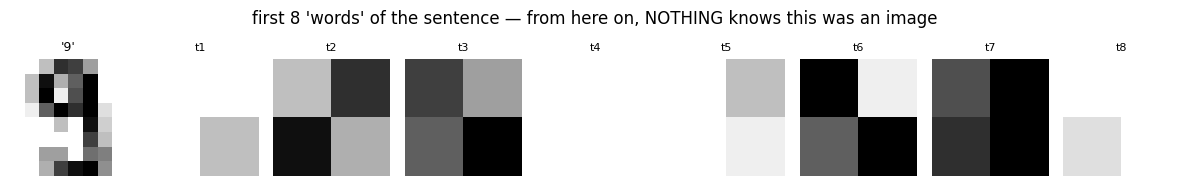

In [2]:
df = pd.read_csv("data/digits_data.csv")
y = df["label"].values
X = df.drop(columns="label").values.reshape(-1, 8, 8)
idx = np.random.default_rng(99).permutation(len(y))       # lesson 11's split seed — comparability
cut = int(0.8*len(y))
tr, te = idx[:cut], idx[cut:]
Xtr_img, Xte_img, ytr, yte = X[tr], X[te], y[tr], y[te]
print(f"{len(tr)} train / {len(te)} test — identical to lesson 11's split")
print("lesson 11 scoreboard to beat: CNN 94.4% clean / 58.9% shifted | MLP 95.6% / 47.5%\n")

PS, NP, PD = 2, 16, 4
def patchify(imgs):
    m = imgs.shape[0]
    return imgs.reshape(m, 4, PS, 4, PS).transpose(0, 1, 3, 2, 4).reshape(m, NP, PD)

d0 = Xte_img[3]
pat0 = patchify(d0[None])[0]
fig, axes = plt.subplots(1, 9, figsize=(12, 1.9))
axes[0].imshow(d0, cmap="gray_r"); axes[0].set_title(f"'{yte[3]}'", fontsize=9); axes[0].axis("off")
for i in range(8):
    axes[i+1].imshow(pat0[i].reshape(2, 2), cmap="gray_r", vmin=0, vmax=1)
    axes[i+1].axis("off"); axes[i+1].set_title(f"t{i+1}", fontsize=8)
plt.suptitle("first 8 'words' of the sentence — from here on, NOTHING knows this was an image")
plt.tight_layout(); plt.show()

## Block 3 — The tokenizer, the blank seat, and positions *(README §3.1)*

The only new equations of the lesson: flatten each patch through ONE shared linear map (note: this IS a stride-2, 2×2 convolution wearing a hat — lesson 11 reappears at the door it was evicted from), prepend a learnable blank CLS token whose only job is to collect the verdict, add positions.

In [3]:
D, HEADS, LAYERS, FF = 48, 4, 2, 128
DH = D // HEADS
T = NP + 1                                                # 16 patches + the CLS seat

def init_vit(seed=0):
    rs = np.random.default_rng(seed)
    def W(*s): return rs.normal(0, 0.15, s)
    P = {"Wp": W(PD, D), "bp": np.zeros(D),               # the tokenizer: 4 pixels -> 48 dims
         "CLS": W(D),                                     # the blank seat (README §3.3)
         "Pos": W(T, D),
         "Wout": W(D, 10), "bout": np.zeros(10), "gF": np.ones(D), "bF": np.zeros(D)}
    for l in range(LAYERS):
        P.update({f"g1_{l}": np.ones(D), f"b1_{l}": np.zeros(D),
                  f"Wq_{l}": W(D, D), f"Wk_{l}": W(D, D), f"Wv_{l}": W(D, D), f"Wo_{l}": W(D, D),
                  f"g2_{l}": np.ones(D), f"b2_{l}": np.zeros(D),
                  f"W1_{l}": W(D, FF), f"c1_{l}": np.zeros(FF),
                  f"W2_{l}": W(FF, D), f"c2_{l}": np.zeros(D)})
    return P

P_demo = init_vit()
emb = patchify(Xtr_img[:2]) @ P_demo["Wp"] + P_demo["bp"]
print(f"tokenizer: patches {patchify(Xtr_img[:2]).shape} -> embeddings {emb.shape}")
print(f"sequence entering the engine: CLS + 16 patch tokens = {T} positions, each {D}-dim")
print(f"tokenizer parameters: {P_demo['Wp'].size + P_demo['bp'].size} — the entire modality adapter")

tokenizer: patches (2, 16, 4) -> embeddings (2, 16, 48)
sequence entering the engine: CLS + 16 patch tokens = 17 positions, each 48-dim
tokenizer parameters: 240 — the entire modality adapter


## Block 4 — The one-line diff *(README §3.2)*

Lesson 14's attention had `S = S + MASK`. Delete it. That single deletion converts a decoder (GPT-shaped: the future is invisible) into an ENCODER (ViT/BERT-shaped: every position sees all others) — because text has an arrow of time and space does not. A digit's top may consult its bottom, freely.

In [4]:
def softmax(Z):
    Z = Z - Z.max(axis=-1, keepdims=True)
    e = np.exp(Z)
    return e / e.sum(axis=-1, keepdims=True)

def layernorm(x, g, b, eps=1e-5):
    mu = x.mean(-1, keepdims=True); var = x.var(-1, keepdims=True)
    xh = (x - mu) / np.sqrt(var + eps)
    return g * xh + b, (xh, np.sqrt(var + eps))

def layernorm_back(dout, g, cache):
    xh, std = cache
    dxh = dout * g
    dg = (dout * xh).sum(axis=(0, 1)); db = dout.sum(axis=(0, 1))
    dx = (dxh - dxh.mean(-1, keepdims=True) - xh * (dxh * xh).mean(-1, keepdims=True)) / std
    return dx, dg, db

def split_heads(x): return x.reshape(x.shape[0], T, HEADS, DH).transpose(0, 2, 1, 3)
def merge_heads(x): return x.transpose(0, 2, 1, 3).reshape(x.shape[0], T, D)

def vit_forward(P, imgs):
    m = imgs.shape[0]
    pat = patchify(imgs)
    Xs = np.concatenate([np.broadcast_to(P["CLS"], (m, 1, D)), pat @ P["Wp"] + P["bp"]], axis=1) + P["Pos"][None]
    caches = []
    Xc = Xs
    for l in range(LAYERS):
        A_in, lc1 = layernorm(Xc, P[f"g1_{l}"], P[f"b1_{l}"])
        Q, K, Vv = split_heads(A_in @ P[f"Wq_{l}"]), split_heads(A_in @ P[f"Wk_{l}"]), split_heads(A_in @ P[f"Wv_{l}"])
        S = Q @ K.transpose(0, 1, 3, 2) / np.sqrt(DH)      # lesson 14 had `+ MASK` here. Deleted.
        A = softmax(S)
        O = merge_heads(A @ Vv) @ P[f"Wo_{l}"]
        X1 = Xc + O
        F_in, lc2 = layernorm(X1, P[f"g2_{l}"], P[f"b2_{l}"])
        Hf = np.maximum(0, F_in @ P[f"W1_{l}"] + P[f"c1_{l}"])
        Xc = X1 + (Hf @ P[f"W2_{l}"] + P[f"c2_{l}"])
        caches.append((A_in, lc1, Q, K, Vv, A, X1, F_in, lc2, Hf))
    Xf, lcF = layernorm(Xc, P["gF"], P["bF"])
    logits = Xf[:, 0] @ P["Wout"] + P["bout"]              # read the blank seat's verdict (README §3.3)
    return logits, (pat, caches, Xf, lcF)

lg, _ = vit_forward(P_demo, Xtr_img[:4])
print(f"forward pass: 4 images -> logits {lg.shape} — the engine ran, unaware it saw pictures")

forward pass: 4 images -> logits (4, 10) — the engine ran, unaware it saw pictures


## Block 5 — Backward + the triple check *(README §3.3)*

Lesson 14's backward with three edits: no mask, gradient enters at seat 0 only, and two new leaf gradients at the bottom (the patch projector and the CLS vector). Checked numerically on three parameter species.

In [5]:
def vit_backward(P, imgs, yv, logits, cache):
    pat, caches, Xf, lcF = cache
    m = len(yv)
    G = {k: np.zeros_like(v) for k, v in P.items()}
    Pr = softmax(logits)
    dlog = (Pr - np.eye(10)[yv]) / m                        # guess − truth, one verdict per image
    G["Wout"] = Xf[:, 0].T @ dlog; G["bout"] = dlog.sum(0)
    dXf = np.zeros_like(Xf)
    dXf[:, 0] = dlog @ P["Wout"].T                          # blame enters at the blank seat only
    dX, G["gF"], G["bF"] = layernorm_back(dXf, P["gF"], lcF)
    for l in range(LAYERS - 1, -1, -1):
        A_in, lc1, Q, K, Vv, A, X1, F_in, lc2, Hf = caches[l]
        dHf = (dX @ P[f"W2_{l}"].T) * (Hf > 0)
        G[f"W2_{l}"] = np.einsum("mtf,mtd->fd", Hf, dX); G[f"c2_{l}"] = dX.sum((0, 1))
        G[f"W1_{l}"] = np.einsum("mtd,mtf->df", F_in, dHf); G[f"c1_{l}"] = dHf.sum((0, 1))
        dX1_ln, G[f"g2_{l}"], G[f"b2_{l}"] = layernorm_back(dHf @ P[f"W1_{l}"].T, P[f"g2_{l}"], lc2)
        dX1 = dX + dX1_ln                                   # the residual '+', as ever
        Om = merge_heads(A @ Vv)
        G[f"Wo_{l}"] = np.einsum("mtd,mte->de", Om, dX1)
        dOhd = split_heads(dX1 @ P[f"Wo_{l}"].T)
        dA = dOhd @ Vv.transpose(0, 1, 3, 2)
        dVv = A.transpose(0, 1, 3, 2) @ dOhd
        dS = (A * (dA - (dA * A).sum(-1, keepdims=True))) / np.sqrt(DH)
        dQ = dS @ K; dK = dS.transpose(0, 1, 3, 2) @ Q
        dA_in = merge_heads(dQ) @ P[f"Wq_{l}"].T + merge_heads(dK) @ P[f"Wk_{l}"].T + merge_heads(dVv) @ P[f"Wv_{l}"].T
        G[f"Wq_{l}"] = np.einsum("mtd,mte->de", A_in, merge_heads(dQ))
        G[f"Wk_{l}"] = np.einsum("mtd,mte->de", A_in, merge_heads(dK))
        G[f"Wv_{l}"] = np.einsum("mtd,mte->de", A_in, merge_heads(dVv))
        dX_ln, G[f"g1_{l}"], G[f"b1_{l}"] = layernorm_back(dA_in, P[f"g1_{l}"], lc1)
        dX = dX1 + dX_ln
    G["Pos"] = dX.sum(0)
    G["CLS"] = dX[:, 0].sum(0)                              # the blank seat learns too
    G["Wp"] = np.einsum("mtp,mtd->pd", pat, dX[:, 1:])      # ...and so does the tokenizer
    G["bp"] = dX[:, 1:].sum((0, 1))
    return G

def ce(logits, yv):
    Pr = softmax(logits)
    return -np.mean(np.log(Pr[np.arange(len(yv)), yv] + 1e-12))

P = init_vit(seed=1)
sub, ysub = Xtr_img[:32], ytr[:32]
lg, ch = vit_forward(P, sub)
G = vit_backward(P, sub, ysub, lg, ch)
eps = 1e-5
for key, idx_ in [("Wq_0", (3, 5)), ("CLS", (7,)), ("Wp", (2, 11))]:
    P[key][idx_] += eps; Lu = ce(vit_forward(P, sub)[0], ysub)
    P[key][idx_] -= 2*eps; Ld = ce(vit_forward(P, sub)[0], ysub)
    P[key][idx_] += eps
    print(f"grad check {key:5s}: analytic {G[key][idx_]:+.7f}  numerical {(Lu-Ld)/(2*eps):+.7f}")

grad check Wq_0 : analytic +0.0070485  numerical +0.0070485
grad check CLS  : analytic +0.0065381  numerical +0.0065381
grad check Wp   : analytic -0.0805334  numerical -0.0805334


## Block 6 — Train, and the clean scoreboard's honest twist *(README §2.4)*

The naive expectation: at 1,437 images, wired-in beliefs (CNN) should beat learned attention. Watch what actually happens — and read the honest interpretation before generalizing it.

In [6]:
class Adam:
    def __init__(self, P, lr):
        self.m = {k: np.zeros_like(v) for k, v in P.items()}
        self.v = {k: np.zeros_like(v) for k, v in P.items()}
        self.lr, self.t = lr, 0
    def step(self, P, G):
        self.t += 1
        for k in P:
            self.m[k] = 0.9*self.m[k] + 0.1*G[k]
            self.v[k] = 0.999*self.v[k] + 0.001*G[k]**2
            mh = self.m[k]/(1-0.9**self.t); vh = self.v[k]/(1-0.999**self.t)
            P[k] -= self.lr * mh/(np.sqrt(vh)+1e-8)

def train_vit(Xi, yv, epochs=60, lr=1e-3, batch=128, seed=0):
    P = init_vit(seed)
    opt = Adam(P, lr)
    rs = np.random.default_rng(seed)
    for ep in range(epochs):
        order = rs.permutation(len(yv))
        for s_ in range(0, len(yv), batch):
            b = order[s_:s_+batch]
            lg, ch = vit_forward(P, Xi[b])
            opt.step(P, vit_backward(P, Xi[b], yv[b], lg, ch))
    return P

def vit_acc(P, Xi, yv): return (vit_forward(P, Xi)[0].argmax(1) == yv).mean()

P_vit = train_vit(Xtr_img, ytr)
acc_vit = vit_acc(P_vit, Xte_img, yte)
print(f"{'model':28s} {'clean test':>10s}")
print(f"{'CNN (lesson 11, 810 params)':28s} {'94.4%':>10s}")
print(f"{'MLP (lesson 11, 2,410)':28s} {'95.6%':>10s}")
print(f"{'ViT (' + format(sum(v.size for v in P_vit.values()), ',') + ' params)':28s} {acc_vit:>10.1%}")
print()
print("The honest twist: the ViT WINS clean, even at this tiny scale — because 8x8 digits are")
print("easy enough that raw capacity covers what the CNN's beliefs would have bought. Do NOT")
print("generalize this against the data-hunger story; the beliefs question is settled where")
print("beliefs DIFFER — the shift test, next block (README §2.4).")

model                        clean test
CNN (lesson 11, 810 params)       94.4%
MLP (lesson 11, 2,410)            95.6%
ViT (45,434 params)               96.7%

The honest twist: the ViT WINS clean, even at this tiny scale — because 8x8 digits are
easy enough that raw capacity covers what the CNN's beliefs would have bought. Do NOT
generalize this against the data-hunger story; the beliefs question is settled where
beliefs DIFFER — the shift test, next block (README §2.4).


## Block 7 — The shift test: the ledger bites *(README §2.4)*

Lesson 11's exact protocol: every test digit shifted 1px right, zero-fill. Nothing in the ViT believes 'a shifted 3 is the same 3' — sixteen independent position embeddings quietly believe the opposite. Prediction: the ViT should be MORE fragile than the CNN here. Measure it.

In [7]:
Xte_sh = np.zeros_like(Xte_img); Xte_sh[:, :, 1:] = Xte_img[:, :, :-1]
acc_vit_sh = vit_acc(P_vit, Xte_sh, yte)
print(f"{'model':28s} {'clean':>7s} {'shifted':>8s} {'drop':>6s}")
print(f"{'CNN (lesson 11)':28s} {'94.4%':>7s} {'58.9%':>8s} {'-35.5':>6s}")
print(f"{'MLP (lesson 11)':28s} {'95.6%':>7s} {'47.5%':>8s} {'-48.1':>6s}")
print(f"{'ViT':28s} {acc_vit:>7.1%} {acc_vit_sh:>8.1%} {100*(acc_vit_sh-acc_vit):>+6.1f}")
print()
print("Confirmed: the ViT is the most shift-fragile model on the board — WORSE than the CNN,")
print("despite winning clean. Fragility lands exactly along the missing belief (README §2.4).")
print("The clean metric flattered it; the delta exposed it. Compare architectures along the")
print("axes their biases govern (README §9, mistake 1).")

model                          clean  shifted   drop
CNN (lesson 11)                94.4%    58.9%  -35.5
MLP (lesson 11)                95.6%    47.5%  -48.1
ViT                            96.7%    50.6%  -46.1

Confirmed: the ViT is the most shift-fragile model on the board — WORSE than the CNN,
despite winning clean. Fragility lands exactly along the missing belief (README §2.4).
The clean metric flattered it; the delta exposed it. Compare architectures along the
axes their biases govern (README §9, mistake 1).


## Block 8 — Augmentation: data stands in for beliefs *(README §2.4)*

The CNN got translation-sameness by WIRING; teach it to the ViT by EXAMPLE — four shifted copies of every training digit. One experiment, the whole modern playbook: weak-bias architecture + manufactured data = the beliefs, purchased.

In [8]:
def shift(imgs, dx, dy):
    out = np.zeros_like(imgs)
    xs = slice(max(dx,0), 8+min(dx,0)); xs_src = slice(max(-dx,0), 8+min(-dx,0))
    ys = slice(max(dy,0), 8+min(dy,0)); ys_src = slice(max(-dy,0), 8+min(-dy,0))
    out[:, ys, xs] = imgs[:, ys_src, xs_src]
    return out

Xaug = np.concatenate([Xtr_img] + [shift(Xtr_img, dx, dy) for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]])
yaug = np.tile(ytr, 5)
print(f"training set: {len(Xtr_img)} -> {len(Xaug)} (original + 4 shifted copies each)")

P_aug = train_vit(Xaug, yaug, epochs=40)
acc_aug, acc_aug_sh = vit_acc(P_aug, Xte_img, yte), vit_acc(P_aug, Xte_sh, yte)
print(f"\n{'model':28s} {'clean':>7s} {'shifted':>8s}")
print(f"{'ViT':28s} {acc_vit:>7.1%} {acc_vit_sh:>8.1%}")
print(f"{'ViT + shift augmentation':28s} {acc_aug:>7.1%} {acc_aug_sh:>8.1%}")
print()
print(f"A {100*(acc_aug_sh-acc_vit_sh):.0f}-point robustness purchase — and clean accuracy IMPROVED too.")
print("Data really can stand in for beliefs. This is why ViT training recipes lean so hard on")
print("augmentation, and — scaled 10^6x — why 'more data' kept beating 'better priors' (README §2.4).")

training set: 1437 -> 7185 (original + 4 shifted copies each)



model                          clean  shifted
ViT                            96.7%    50.6%
ViT + shift augmentation       98.6%    96.1%

A 46-point robustness purchase — and clean accuracy IMPROVED too.
Data really can stand in for beliefs. This is why ViT training recipes lean so hard on
augmentation, and — scaled 10^6x — why 'more data' kept beating 'better priors' (README §2.4).


## Block 9 — Where the verdict looks, and do positions discover 2D? *(README §2.5 + §5)*

(a) The CLS token's attention over the patches, per head — attention-as-sight. (b) The classic ViT diagnostic: our position embeddings were initialized flat, knowing nothing of geometry. After training, are NEIGHBORING patches' embeddings more similar than distant ones? If yes: the model LEARNED 2D structure from data — the lesson's thesis in miniature.

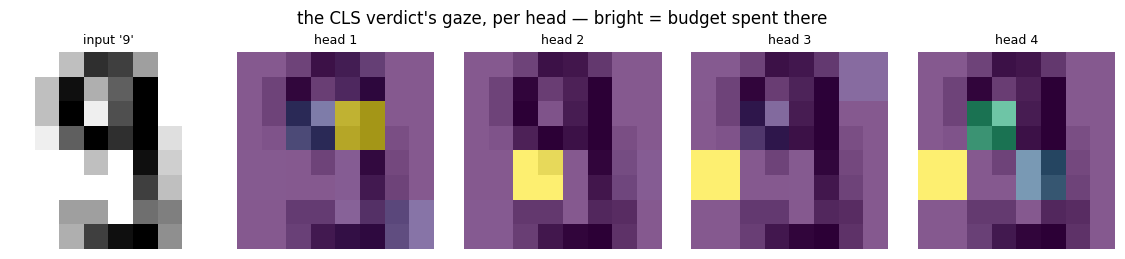

position-embedding cosine similarity — adjacent patches: +0.02 | distant patches: -0.04
Directionally right, but WEAK (gap +0.05): neighbors are only slightly more similar
than strangers. Honest reading: at 16 patches and 2 layers the model barely needed the
geometry — the classic clean checkerboard emerges at real ViT scale (196+ patches), where
position structure genuinely pays rent. Direction confirmed; magnitude, not yet (README §5).


In [9]:
lgv, chv = vit_forward(P_vit, Xte_img[:200])
A_last = chv[1][-1][5]
fig, axes = plt.subplots(1, 5, figsize=(11.5, 2.6))
axes[0].imshow(Xte_img[3], cmap="gray_r"); axes[0].set_title(f"input '{yte[3]}'", fontsize=9); axes[0].axis("off")
for h in range(4):
    cls_row = A_last[3, h, 0, 1:].reshape(4, 4)
    axes[h+1].imshow(np.kron(cls_row, np.ones((2, 2))), cmap="viridis")
    axes[h+1].imshow(Xte_img[3], cmap="gray_r", alpha=0.35)
    axes[h+1].set_title(f"head {h+1}", fontsize=9); axes[h+1].axis("off")
plt.suptitle("the CLS verdict's gaze, per head — bright = budget spent there")
plt.tight_layout(); plt.show()

pos = P_vit["Pos"][1:]                                     # the 16 patch positions
pos_n = pos / np.linalg.norm(pos, axis=1, keepdims=True)
sim = pos_n @ pos_n.T
coords = np.array([(i // 4, i % 4) for i in range(16)])
dists = np.abs(coords[:, None, :] - coords[None, :, :]).sum(-1)
adj = sim[dists == 1].mean(); far = sim[dists >= 4].mean()
print(f"position-embedding cosine similarity — adjacent patches: {adj:+.2f} | distant patches: {far:+.2f}")
gap = adj - far
if gap > 0.15:
    print("Neighbors became clearly more similar than strangers: the flat embeddings discovered")
    print("the 2D grid from gradient pressure alone (README §5).")
elif gap > 0:
    print(f"Directionally right, but WEAK (gap {gap:+.2f}): neighbors are only slightly more similar")
    print("than strangers. Honest reading: at 16 patches and 2 layers the model barely needed the")
    print("geometry — the classic clean checkerboard emerges at real ViT scale (196+ patches), where")
    print("position structure genuinely pays rent. Direction confirmed; magnitude, not yet (README §5).")
else:
    print("On this run geometry did not emerge in the position embeddings — the model found another")
    print("route to the task. The classic result appears at real ViT scale.")

## Block 10 — The scale story, told straight *(README §6)*

What our miniature fight does and does not prove — then the door to lesson 16.

In [10]:
print("WHAT WE MEASURED, AND WHAT IT MEANS:")
print(f"  clean: ViT {acc_vit:.0%} > CNN 94% — capacity covered for beliefs on an EASY task.")
print(f"  shifted: ViT {acc_vit_sh:.0%} < CNN 59% — fragility exactly along the missing belief.")
print(f"  augmented: {acc_aug:.0%}/{acc_aug_sh:.0%} — data purchased the belief back, with interest.")
print()
print("Scaled up, the same forces produced the ViT paper's crossover: below ~tens of millions")
print("of images, CNN priors win; above, the ViT's freedom wins (nothing wrong to unlearn,")
print("global sight from layer 1, and the engine shared with language).")
print()
print("THE DOOR: 'shared with language' is not a slogan. Lesson 16 plugs BOTH adapters into")
print("the framework at once — an image tower and a text tower trained together, so a photo")
print("and its caption land on the same point. The contrastive trick behind CLIP awaits.")

WHAT WE MEASURED, AND WHAT IT MEANS:
  clean: ViT 97% > CNN 94% — capacity covered for beliefs on an EASY task.
  shifted: ViT 51% < CNN 59% — fragility exactly along the missing belief.
  augmented: 99%/96% — data purchased the belief back, with interest.

Scaled up, the same forces produced the ViT paper's crossover: below ~tens of millions
of images, CNN priors win; above, the ViT's freedom wins (nothing wrong to unlearn,
global sight from layer 1, and the engine shared with language).

THE DOOR: 'shared with language' is not a slogan. Lesson 16 plugs BOTH adapters into
the framework at once — an image tower and a text tower trained together, so a photo
and its caption land on the same point. The contrastive trick behind CLIP awaits.


---
## What you now own

- The tokenizer as the modality adapter (and its secret: it IS a strided convolution)
- The one-line diff (mask deleted) = decoder → encoder, touched with your own hands
- The CLS seat: a learned blank that collects the verdict, with legible receipts
- The fight, measured honestly: clean twist, shift confirmation, augmentation purchase — beliefs as a loan against data
- The 2D-discovery diagnostic: geometry emerging (or not) from flat embeddings

**Next:** `vit_with_library.ipynb` — then folder `16-multimodal-clip`: two adapters, one space.